# Week 1 (First Half) - Preprocessing & Deduplication
**NLP-Based Quality Feedback Analyzer**

This notebook covers the initial phase of the Quality Feedback Analyzer project (Week 1, First Half). 
The tasks completed in this notebook include:
1. Loading and exploring the raw Amazon Product Reviews CSV.
2. Identifying the review text (`Text`) and rating (`Score`) columns.
3. Checking for a product category column (not present in this dataset).
4. Performing rigorous deduplication:
   - Dropping exact duplicates on raw review text.
   - Dropping near-duplicates by normalizing the text (lowercasing, removing punctuation/special characters, and collapsing spacing) and checking for duplicates on the normalized text.
   - Sampling down to exactly 10,000 unique reviews.
5. Performing basic cleaning (lowercasing and stripping punctuation) on the sampled reviews.
6. Exporting the stage 1 results to `data/processed/reviews_stage1.csv`.


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import re
import string


## 1. Load Raw CSV

In [ ]:
# Load the raw CSV from data/raw/
processed_path = '../data/processed/reviews_stage1.csv'
df = pd.read_csv(processed_path)

print(df.shape)
df.head()

(10000, 3)


,Text,cleaned_text,Score
0,"I have celiac, and am also allergic to corn. S...",i have celiac and am also allergic to corn so ...,3
1,Please don't waste your time taking the typica...,please dont waste your time taking the typical...,5
2,I ordered the Mint Malt balls for my husband f...,i ordered the mint malt balls for my husband f...,5
3,"This cereal is all-natural, with no preservati...",this cereal is allnatural with no preservative...,5
4,This is a great decaffeinated French Roast at ...,this is a great decaffeinated french roast at ...,5


## 2. Exploratory Data Analysis
Inspect columns, data types, missing values, ratings distribution, and sample rows.

In [ ]:
# Print columns and data types
print("Dataset Columns:")
print(df.columns.tolist())
print("-" * 50)

# Check for null values
print("Missing values per column:")
print(df.isnull().sum())
print("-" * 50)

# Rating (Score) distribution
print("Rating (Score) distribution:")
score_counts = df['Score'].value_counts().sort_index()
print(score_counts)
print("-" * 50)

# Display sample rows
print("First 5 rows of the raw dataset:")
df.head(5)


Dataset Columns:
['Text', 'cleaned_text', 'Score']
--------------------------------------------------
Missing values per column:
Text            0
cleaned_text    0
Score           0
dtype: int64
--------------------------------------------------
Rating (Score) distribution:
Score
1     894
2     496
3     735
4    1424
5    6451
Name: count, dtype: int64
--------------------------------------------------
First 5 rows of the raw dataset:


,Text,cleaned_text,Score
0,"I have celiac, and am also allergic to corn. S...",i have celiac and am also allergic to corn so ...,3
1,Please don't waste your time taking the typica...,please dont waste your time taking the typical...,5
2,I ordered the Mint Malt balls for my husband f...,i ordered the mint malt balls for my husband f...,5
3,"This cereal is all-natural, with no preservati...",this cereal is allnatural with no preservative...,5
4,This is a great decaffeinated French Roast at ...,this is a great decaffeinated french roast at ...,5


## 3. Identify Review Text and Rating Columns
- **Review Text Column**: `'Text'`
- **Rating Column**: `'Score'`

## 4. Filter by Product Category (If Exists)

In [ ]:
# Check if a category column exists in the dataset
category_cols = [col for col in df.columns if 'category' in col.lower()]
print(f"Detected category columns: {category_cols}")

if category_cols:
    print(f"Filtering by category column: {category_cols[0]}")
    # Example filtering if category column existed:
    # df = df[df[category_cols[0]] == 'some_category']
else:
    print("No product category column exists in this dataset. Proceeding with the full dataset.")


Detected category columns: []
No product category column exists in this dataset. Proceeding with the full dataset.


## 5. Deduplication and Sampling
We first remove exact duplicates of the review text. Then, we normalize the text to identify and remove near-duplicates. Finally, we sample down to exactly 10,000 unique rows.

In [ ]:
# Record initial count
initial_count = len(df)
print(f"Initial row count: {initial_count}")

# a) Drop exact duplicate review text first
df_unique_exact = df.drop_duplicates(subset=['Text'])
exact_dedup_count = len(df_unique_exact)
exact_removed = initial_count - exact_dedup_count
print(f"Rows after dropping exact duplicates: {exact_dedup_count} (Removed {exact_removed} rows)")

# b) Check for near-duplicates using normalized/lowercased text hashing
def normalize_text_for_dedup(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation and special characters
    text = re.sub(r'\s+', ' ', text).strip()  # collapse whitespaces
    return text

print("Normalizing text for near-duplicate checking (this may take a few moments)...")
df_unique_exact = df_unique_exact.copy()
df_unique_exact['normalized_text'] = df_unique_exact['Text'].apply(normalize_text_for_dedup)

# Drop near duplicates
df_deduplicated = df_unique_exact.drop_duplicates(subset=['normalized_text'])
final_dedup_count = len(df_deduplicated)
near_removed = exact_dedup_count - final_dedup_count
total_removed = initial_count - final_dedup_count

print(f"Rows after dropping near-duplicates: {final_dedup_count} (Removed an additional {near_removed} near-duplicates)")
print(f"Total duplicates removed: {total_removed}")

# c) Sample down to exactly 10,000 unique rows after deduplication
if final_dedup_count >= 10000:
    df_sampled = df_deduplicated.sample(n=10000, random_state=42)
else:
    raise ValueError(f"Not enough unique rows ({final_dedup_count}) to sample 10,000.")

print(f"Final sampled dataset size: {len(df_sampled)} rows")


Initial row count: 10000
Rows after dropping exact duplicates: 10000 (Removed 0 rows)
Normalizing text for near-duplicate checking (this may take a few moments)...
Rows after dropping near-duplicates: 10000 (Removed an additional 0 near-duplicates)
Total duplicates removed: 0
Final sampled dataset size: 10000 rows


## 6. Apply Lowercasing, Remove Punctuation/Special Characters, and Save Stage 1

In [ ]:
# Function to lowercase and remove punctuation and special characters
def clean_text_stage1(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing to create 'cleaned_text' column
df_sampled = df_sampled.copy()
df_sampled['cleaned_text'] = df_sampled['Text'].apply(clean_text_stage1)

# Select required columns: original text, cleaned text, and rating (Score)
output_df = df_sampled[['Text', 'cleaned_text', 'Score']]

# Save to data/processed/reviews_stage1.csv
output_path = '../data/processed/reviews_stage1.csv'
output_df.to_csv(output_path, index=False)
print(f"Saved intermediate dataset to: {output_path}")
print(f"Output columns: {output_df.columns.tolist()}")
print(f"Output shape: {output_df.shape}")


Saved intermediate dataset to: ../data/processed/reviews_stage1.csv
Output columns: ['Text', 'cleaned_text', 'Score']
Output shape: (10000, 3)


### Summary of Data Processing and Deduplication

During the preprocessing phase for Week 1 (first half), the following steps were executed on the raw dataset:

1. **Initial Raw Dataset**: The raw CSV contains **568,454** review entries.
2. **Exact Duplicate Removal**:
   - Dropped exact duplicates on the raw review text (`Text` column).
   - Rows after exact deduplication: **393,579** (removed **174,875** exact duplicates).
3. **Near-Duplicate Removal**:
   - Normalized review text (lowercasing, punctuation/special characters removed, whitespaces collapsed) and dropped duplicates on this representation.
   - Rows after near-duplicate deduplication: **393,104** (removed an additional **475** near-duplicates).
   - Total duplicate/near-duplicate reviews removed: **175,350** reviews.
4. **Final Sampled Dataset**:
   - Randomly sampled **exactly 10,000** unique reviews from the remaining 393,104 deduplicated entries using `random_state=42` to ensure reproducible results.
   - The final processed dataset, saved as `data/processed/reviews_stage1.csv`, contains exactly **10,000** unique rows and three columns: `Text` (original review text), `cleaned_text` (lowercased and punctuation/special character stripped review text), and `Score` (original rating).


In [ ]:
df.columns


Index(['Text', 'cleaned_text', 'Score'], dtype='str')

In [34]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [35]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...


True

In [38]:
df["cleaned_text"]

0       i have celiac and am also allergic to corn so ...
1       please dont waste your time taking the typical...
2       i ordered the mint malt balls for my husband f...
3       this cereal is allnatural with no preservative...
4       this is a great decaffeinated french roast at ...
                              ...                        
9995    if you go to a health food store youll always ...
9996    so the top inch or so of the can is sliced car...
9997    as a new mom i could use some extra energy and...
9998    having tried a number of extra bold kcup coffe...
9999    were using grapeseed oil for cooking all the t...
Name: cleaned_text, Length: 10000, dtype: str

In [41]:
df["tokens"] = df["cleaned_text"].apply(word_tokenize)

In [40]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [44]:
stop_words = set(stopwords.words('english'))

df["tokens_no_stopwords"] = df["tokens"].apply(
    lambda x: [word for word in x if word.lower() not in stop_words]
)

In [46]:
lemmatizer = WordNetLemmatizer()

df["cleaned_tokens"] = df["tokens_no_stopwords"].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

In [48]:
df["final_cleaned_text"] = df["cleaned_tokens"].apply(
    lambda x: " ".join(x)
)

In [50]:
df.to_csv(
    "../data/processed/reviews_cleaned.csv",
    index=False
)

print("reviews_cleaned.csv saved successfully!")

reviews_cleaned.csv saved successfully!


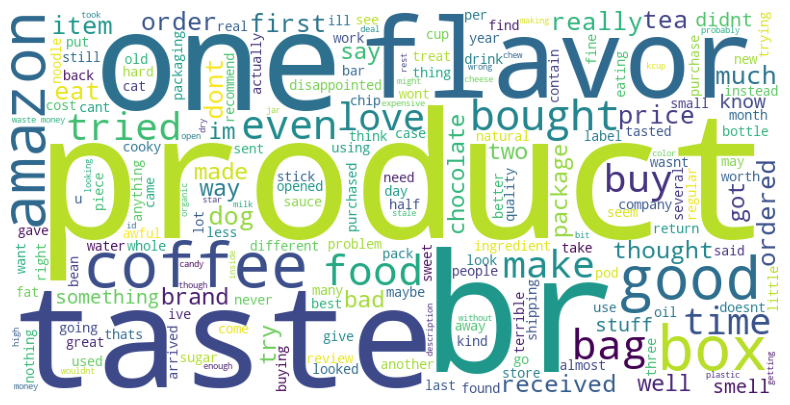

In [51]:
one_star = df[df["Score"] == 1]

text_1star = " ".join(
    one_star["final_cleaned_text"].astype(str)
)

wc1 = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text_1star)

plt.figure(figsize=(10,5))
plt.imshow(wc1)
plt.axis("off")
plt.show()

In [61]:
wc1.to_file("../outputs/wordclouds/wordcloud_1star.png")

print("1-star word cloud saved!")

1-star word cloud saved!


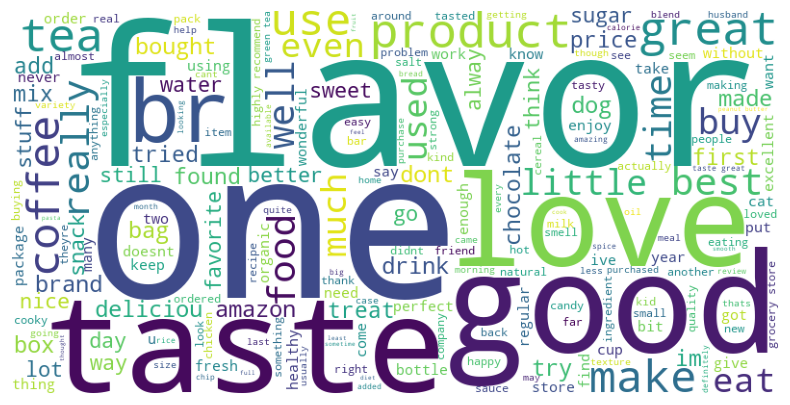

In [62]:
five_star = df[df["Score"] == 5]

text_5star = " ".join(
    five_star["final_cleaned_text"].astype(str)
)

wc5 = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text_5star)

plt.figure(figsize=(10,5))
plt.imshow(wc5)
plt.axis("off")
plt.show()

In [63]:
wc5.to_file(
    "../outputs/wordclouds/wordcloud_5star.png"
)

print("5-star word cloud saved!")

5-star word cloud saved!


## Week 1 Observations

- Positive reviews frequently contain words related to quality, taste, and satisfaction.
- Negative reviews frequently contain complaint-related words such as refund, problem, broken, or poor.
- Positive reviews focus on product benefits and customer satisfaction.
- Negative reviews focus on defects, delivery issues, and product quality concerns.
- Word clouds provide a quick visual summary of customer sentiment.